In [3]:
import heapq
import networkx as networkx
import matplotlib.pyplot as plt

graph= {'A': [('B',1), ('C',4)], 
'B': [('D',2), ('E',5)], 
'C':[('F',1)], 
'D':[], 
'E':[('G',2)], 
'F': [('G',3)], 
'G':[]}

heuristic= {'A':7, 'B':6, 'C':2, 'D':5, 'E':2, 'F':1, 'G':0}

def astar(graph, heuristic,start,goal):
    pq= [(heuristic[start],0,start, [start])]
    visited = set()

    while pq:
        f, g, node, path= heapq.heappop(pq)

        if node== goal:
            return path, g 
        if node in visited:
            continue
        visited.add(node)

        for neigbour,cost in graph[node]:
            new_g= g+cost
            new_f= new_g + heuristic[neigbour]
            new_path = path + [neigbour]
            heapq.heappush(pq, (new_f, new_g, neigbour, new_path))
    return None, float('inf')

path, cost= astar(graph, heuristic, 'A', 'G')

print("Shortest Path:")
print("->".join(path))
print("Total Cost:", cost)

Shortest Path:
A->B->E->G
Total Cost: 8


Shortest Path
A->B->E->G
Total Cost: 8


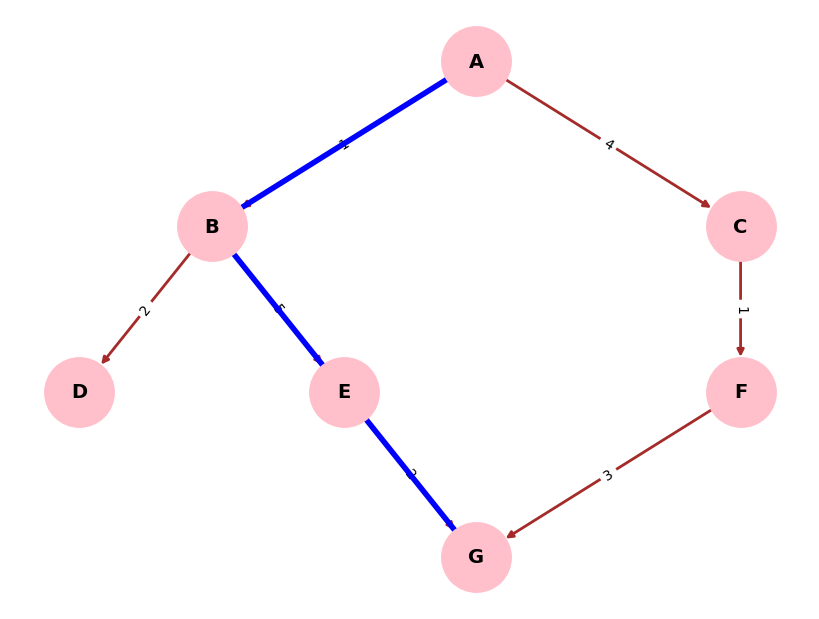

In [8]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt
graph={
    'A':[('B',1),('C',4)],
    'B':[('D',2),('E',5)],
    'C':[('F',1)],
    'D':[],
    'E':[('G',2)],
    'F':[('G',3)],
    'G':[]
}
heuristic={
    'A':7,
    'B':6,
    'C':2,
    'D':5,
    'E':2,
    'F':1,
    'G':0
}
def astar(graph,heuristic,start,goal):
    pq=[(heuristic[start],0,start,[start])]
    visited=set()
    while pq:
        f,g,node,path=heapq.heappop(pq)
        if node==goal:
            return path,g
        if node in visited:
            continue
        visited.add(node)
        for neighbor,cost in graph[node]:
            new_g = g + cost
            new_f = new_g+heuristic[neighbor]
            heapq.heappush(pq,(new_f,new_g,neighbor,path+[neighbor]))
    return None,float('inf')
path,cost=astar(graph,heuristic,'A','G')
print("Shortest Path")
print("->".join(path))
print("Total Cost:",cost)
G= nx.DiGraph()
for node in graph:
    for neighbor, weight in graph[node]:
        G.add_edge(node,neighbor,weight=weight)
pos= {'A':(0,3), 
      'B':(-1,2), 
      'C':(1,2), 
      'D':(-1.5,1), 
      'E':(-0.5,1), 
      'F':(1,1), 
      'G':(0,0)
}
plt.figure(figsize=(8,6))
nx.draw(
    G,pos,
    with_labels=True,
    node_color='pink',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='brown',
    arrows=True,
    width=2
)
edge_labels=nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)
path_edges=list(zip(path[:-1],path[1:]))
nx.draw_networkx_edges(
    G,pos,edgelist=path_edges,
    edge_color='blue',
    width=4,
    arrows=True
)

In [23]:
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': {'type': 'OR', 'children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND', 'children': [('D', 1), ('E', 1)]},
    'C': {'type': 'OR', 'children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 6}
}

# AO* Cost Calculation
def ao_star(node):
    info = graph[node]

    # Leaf node
    if info['type'] == 'LEAF':
        return info['cost'], [node]

    # OR node
    if info['type'] == 'OR':
        best_cost = float("inf")
        best_path = []

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total = edge_cost + child_cost

            if total < best_cost:
                best_cost = total
                best_path = [node] + child_path

        return best_cost, best_path

    # AND node
    if info['type'] == 'AND':
        total_cost = 0
        full_path = [node]

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path

        return total_cost, full_path


# Run AO*
cost, path = ao_star('A')

print("Optimal Solution Path:")
print(" -> ".join(path))
print("Total Cost:", cost)

Optimal Solution Path:
A -> C -> F
Total Cost: 6


Optimal Solution Path: 
A->C->F
Total Cost:  6


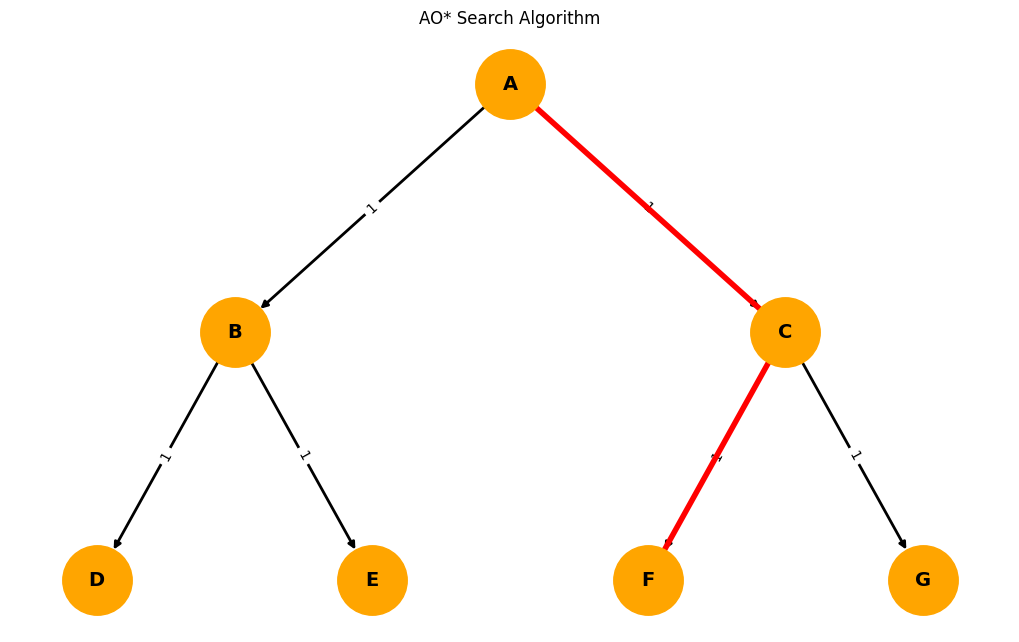

In [1]:
#AO* GRAPH
import networkx as nx
import matplotlib.pyplot as plt

graph= {
    'A': {'type': 'OR', 'children': [('B',1),('C',1)]},
    'B': {'type': 'AND', 'children': [('D',1),('E',1)]},
    'C': {'type': 'OR', 'children': [('F',1),('G',1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 6}
    }

def ao_star(node):
    # Evaluate all nodes using a recursive bottom-up approach
    info = graph[node]
    
    # 1. Leaf Node
    if info['type'] == 'LEAF':
        return info['cost'], [node]

    # 2. Apply OR/AND logic
    if info['type'] == 'OR':
        best_cost= float('inf')
        best_path=[]

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total= edge_cost+ child_cost
            
            if total< best_cost:
                best_cost= total
                best_path =  [node] + child_path
        
        return best_cost, best_path
    
    elif info['type'] == 'AND':
        total_cost=0
        full_path=[node]

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path
        
        return total_cost, full_path

cost, path= ao_star('A')

print("Optimal Solution Path: ")
print("->".join(path))
print("Total Cost: ",cost)

G= nx.DiGraph()
for node,info in graph.items():
    if 'children' in info:
        for child, weight in info['children']:
            G.add_edge(node, child, weight=weight)
pos= {
    'A': (0,3),
    'B': (-1,2),
    'C': (1,2),
    'D': (-1.5, 1),
    'E': (-0.5, 1),
    'F': (0.5, 1),
    'G': (1.5, 1)
}
plt.figure(figsize=(10,6))
colors= []
for n in G.nodes():
    t= graph[n]['type']
    if t== 'OR':
        colors.append('skyblue')
    elif t== 'AND':
        colors.append('lightgreen')
    else:
        colors.append('orange')
nx.draw(G, pos, with_labels=True, node_size=2500, node_color='orange', font_size=14, font_weight='bold', arrows=True, width=2)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Highlight the shortest path
path_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_edges, width=4, edge_color='red', arrows= True)   

plt.title("AO* Search Algorithm")
plt.axis('off')
plt.show()